# 01 — Data cleaning and exploratory analysis

**Business question:** which customers are leaving, and where is the revenue risk concentrated?

The dataset is the public [Telco Customer Churn dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
(7,043 customers), deliberately framed as a subscription/SaaS-style business — see
`data-sources.md` for why that framing is reasonable and where it isn't.

All reusable logic lives in `src/`; this notebook is the narrative walkthrough.

In [1]:
# Make the repo root importable when running from /notebooks
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from IPython.display import Image

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

In [2]:
from src.data_prep import load_raw, prepare

raw = load_raw()
raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data quality

Three issues worth documenting (all handled in `src/data_prep.py`):

1. **`TotalCharges` is stored as text with 11 blank values.** Every blank belongs to a
   customer with `tenure == 0` — brand-new accounts that haven't been billed yet. They are
   set to \$0 rather than dropped, because "new, unbilled customer" is real information.
2. **`SeniorCitizen` is coded 0/1** while every other yes/no column is "Yes"/"No" — recoded
   for consistency.
3. **No duplicate customer IDs, no other missing values.**

In [3]:
# The 11 blank TotalCharges rows are all tenure-0 customers
blank = raw[raw["TotalCharges"].astype(str).str.strip() == ""]
blank[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [4]:
df = prepare()   # clean + derived features (tenure bands, charge tiers, service counts)
print(f"{len(df):,} customers | overall churn rate {df['churn_flag'].mean():.1%} "
      f"| avg monthly charge ${df['MonthlyCharges'].mean():.2f}")

7,043 customers | overall churn rate 26.5% | avg monthly charge $64.76


## Where churn concentrates

Churn rate by each of the main segmentation dimensions. The tables are the evidence;
the exported figures (also used in the strategy deck) are shown inline.

In [5]:
from src.eda import churn_rate_by

churn_rate_by(df, "Contract").round(3)

,customers,churn_rate,mrr,mrr_share
Contract,,,,
Month-to-month,3875,0.427,257294.15,0.564
One year,1473,0.113,95816.60,0.210
Two year,1695,0.028,103005.85,0.226


In [6]:
churn_rate_by(df, "tenure_band").round(3)

,customers,churn_rate,mrr,mrr_share
tenure_band,,,,
0-6m,1481,0.529,81067.95,0.178
7-12m,705,0.359,41561.80,0.091
13-24m,1024,0.287,62829.85,0.138
25-48m,1594,0.204,105093.30,0.230
49-72m,2239,0.095,165563.70,0.363


In [7]:
churn_rate_by(df, "PaymentMethod").round(3)

,customers,churn_rate,mrr,mrr_share
PaymentMethod,,,,
Bank transfer (automatic),1544,0.167,103745.45,0.227
Credit card (automatic),1522,0.152,101231.85,0.222
Electronic check,2365,0.453,180345.00,0.395
Mailed check,1612,0.191,70794.30,0.155


In [8]:
churn_rate_by(df, "charge_tier").round(3)

,customers,churn_rate,mrr,mrr_share
charge_tier,,,,
<$35,1731,0.109,38077.15,0.083
$35-70,1721,0.236,94177.15,0.206
$70-90,1847,0.380,147740.80,0.324
$90+,1744,0.329,176121.50,0.386


In [9]:
# Add-on depth: internet customers only (others can't buy add-ons)
churn_rate_by(df[df["InternetService"] != "No"], "n_addon_services").round(3)

,customers,churn_rate,mrr,mrr_share
n_addon_services,,,,
0,693,0.522,40600.60,0.096
1,966,0.458,63344.75,0.149
2,1033,0.358,74807.25,0.176
3,1118,0.274,89563.55,0.211
4,852,0.223,74781.35,0.176
5,571,0.124,52632.50,0.124
6,284,0.053,28219.75,0.067


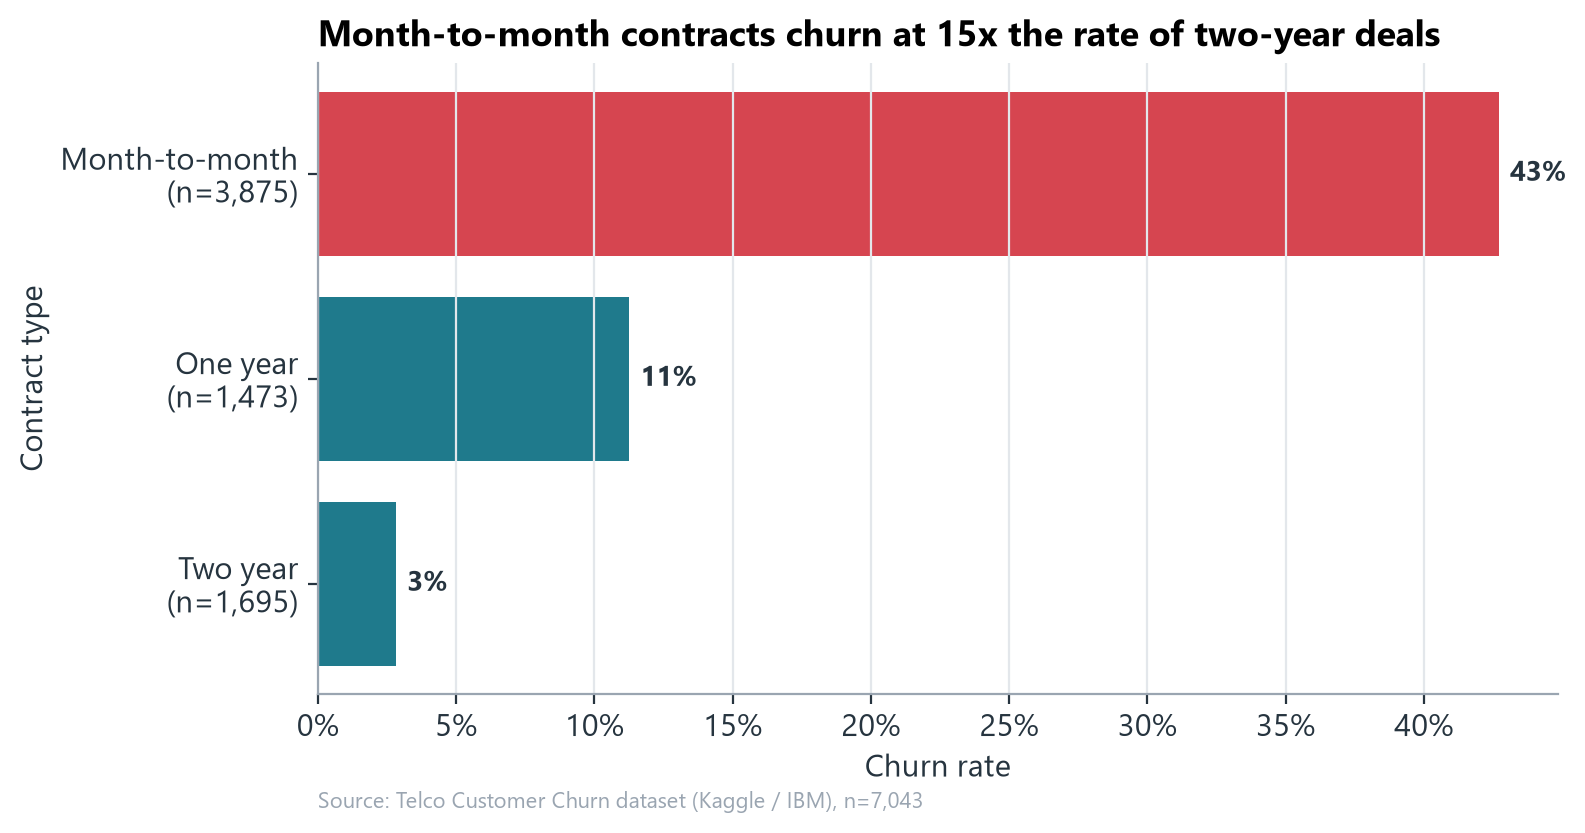

In [10]:
from src.eda import run_eda

figures = run_eda(df)   # regenerates reports/figures/*.png
Image(figures["contract"])

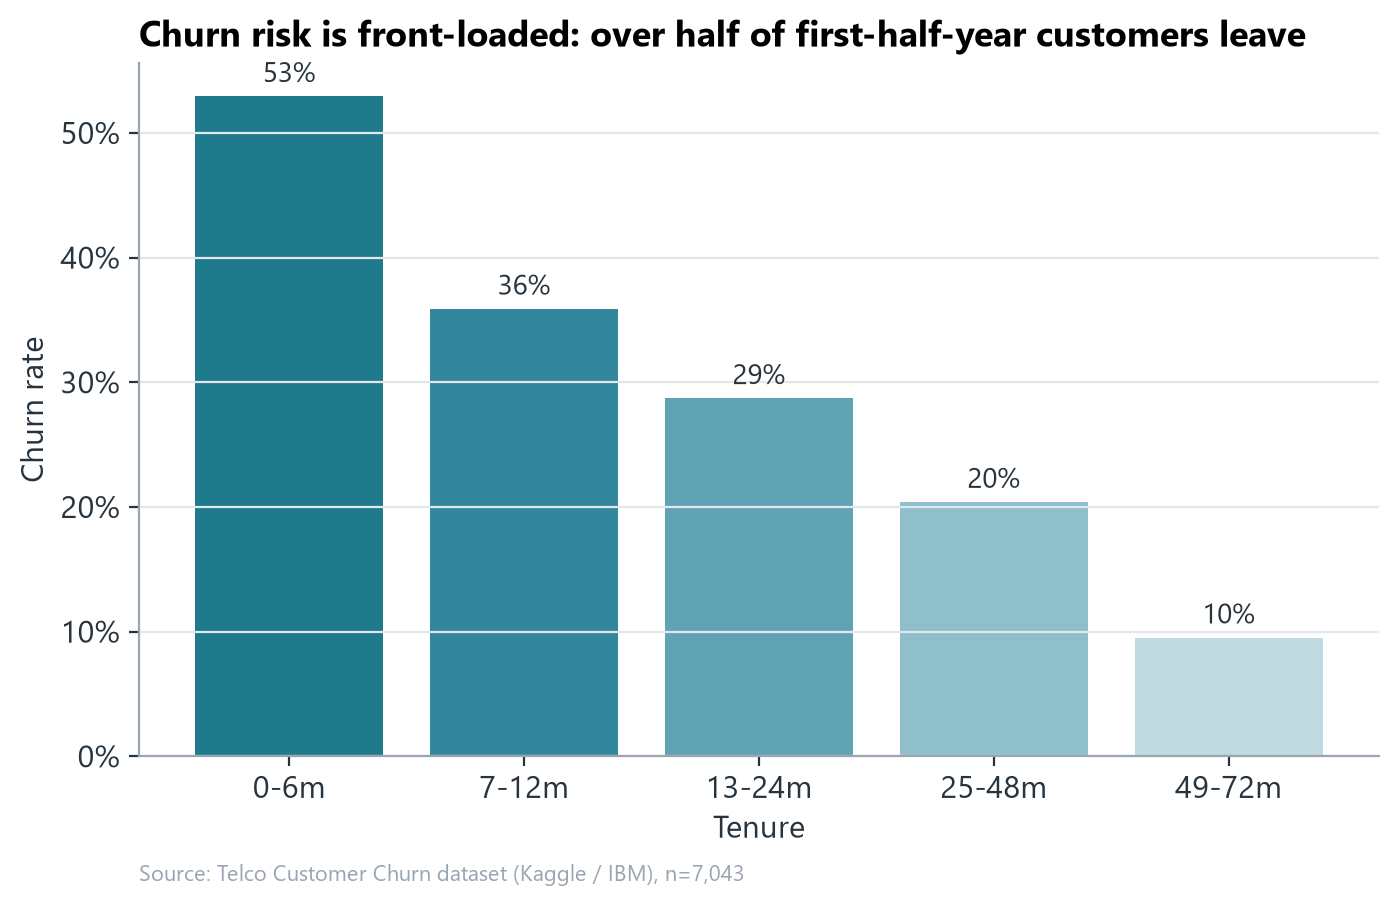

In [11]:
Image(figures["tenure"])

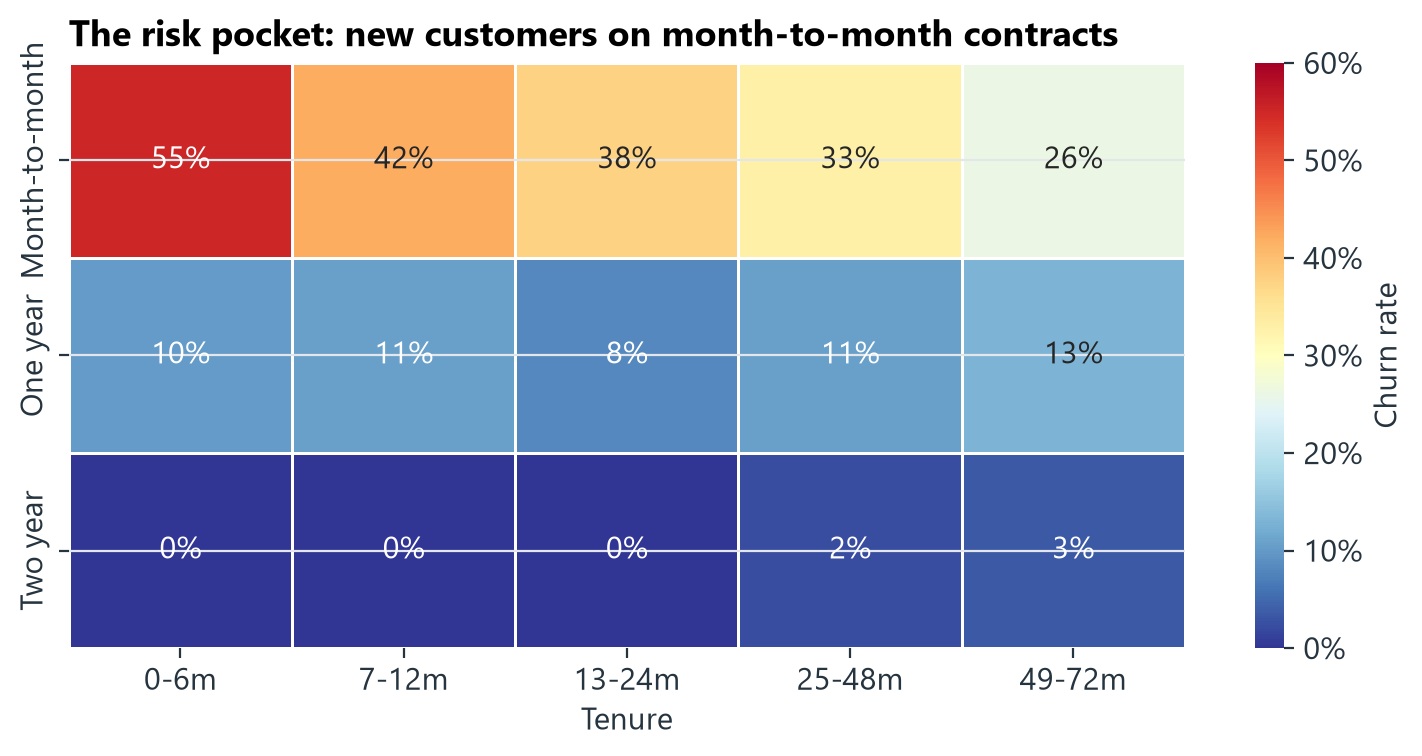

In [12]:
Image(figures["heatmap"])

## At-risk customer profiles

Simple, targetable segments built from the patterns above (they overlap — each is judged
against the whole book). Every one churns at roughly **2x the base rate or worse**.

In [13]:
from src.eda import at_risk_segments

seg = at_risk_segments(df)
seg.style.format({"share_of_base": "{:.0%}", "churn_rate": "{:.1%}",
                  "avg_monthly_charge": "${:.2f}", "mrr": "${:,.0f}",
                  "mrr_lost_to_churn": "${:,.0f}"})

,customers,share_of_base,churn_rate,avg_monthly_charge,mrr,mrr_lost_to_churn
segment,,,,,,
New month-to-month (tenure <= 12m),1994,28%,51.4%,$58.22,"$116,086","$68,301"
Month-to-month + electronic check,1850,26%,53.7%,$74.99,"$138,731","$77,316"
"Fiber, no support/security add-ons",1765,25%,55.0%,$86.10,"$151,964","$82,818"
"Premium charges ($90+), first year",219,3%,75.8%,$96.60,"$21,156","$16,079"
Whole customer base (reference),7043,100%,26.5%,$64.76,"$456,117","$139,131"


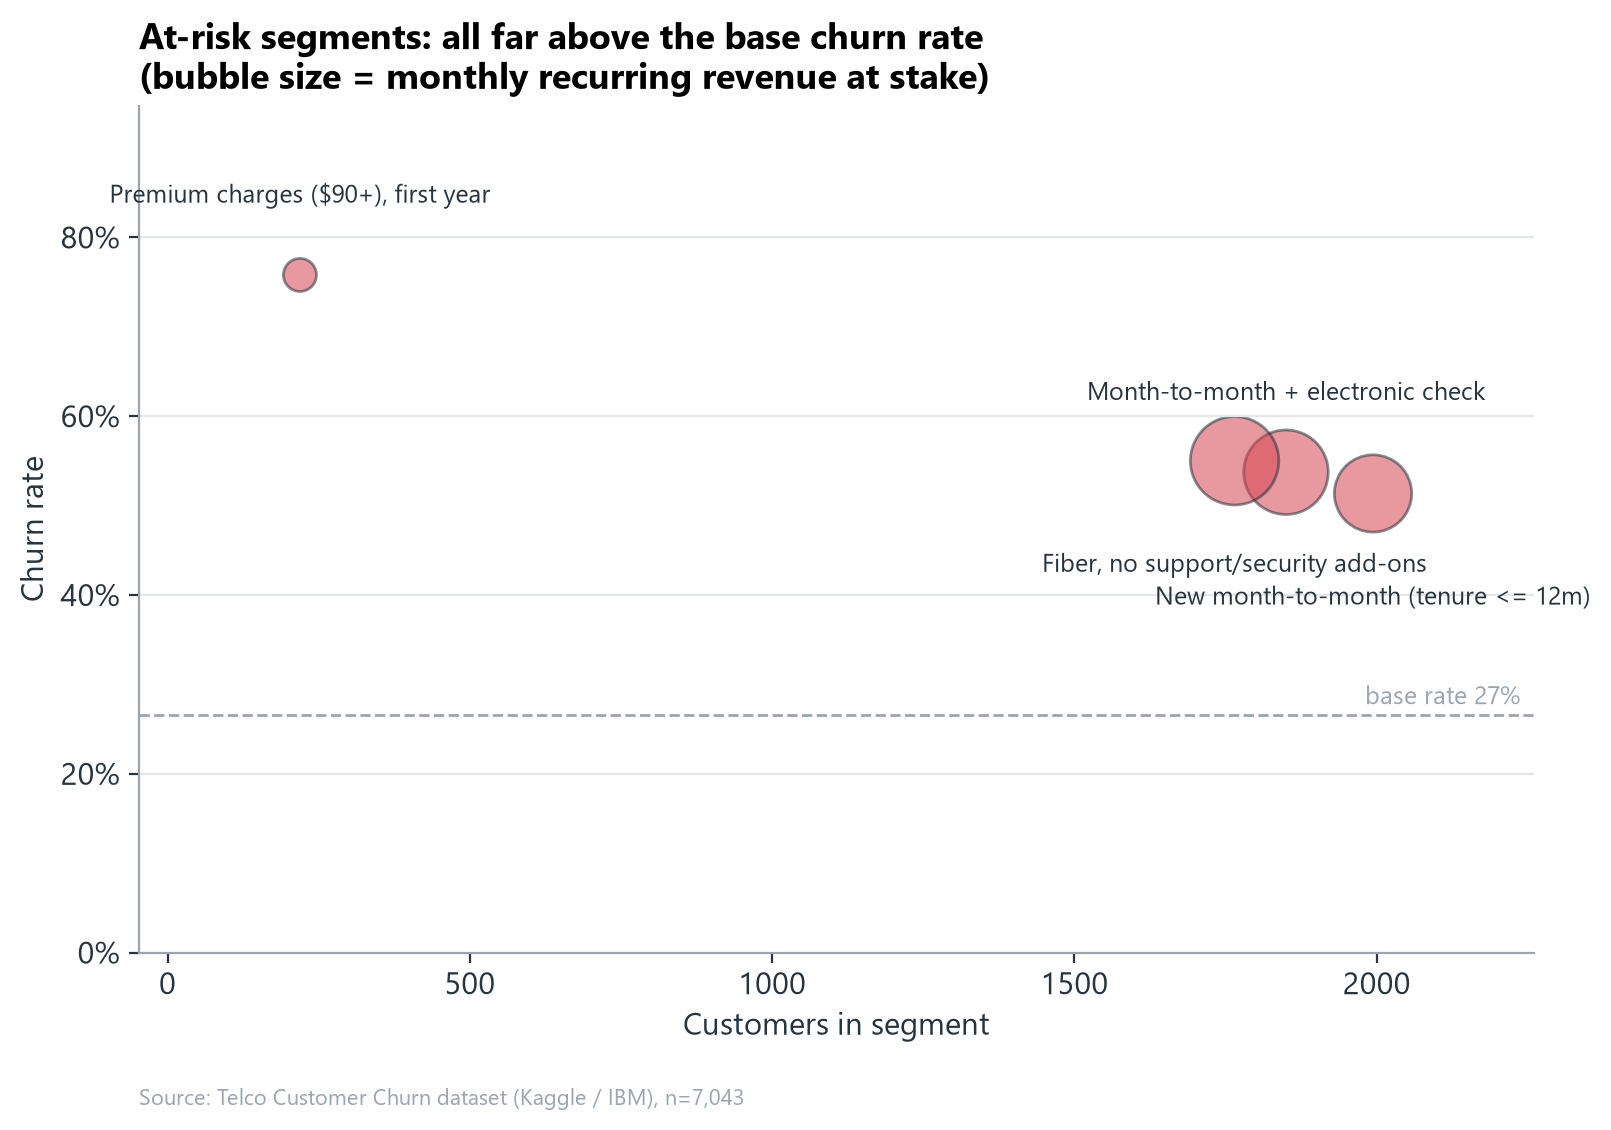

In [14]:
Image(figures["segments"])

## Takeaways

1. **Contract type is the fault line.** Month-to-month customers churn at 43% vs 3% on
   two-year contracts — and they are 55% of the book.
2. **Risk is front-loaded.** 53% of customers in their first 6 months churn; survive the
   first year and risk drops fast.
3. **The expensive tier is the leaky tier.** Churn peaks at \$70–90/month (38%) — these are
   mostly fiber customers without support add-ons. This is a price/value problem, not a
   cheap-customer problem: the \$70+ tiers hold ~71% of MRR.
4. **Add-ons anchor customers.** Among internet customers, churn falls monotonically from
   52% (no add-ons) to 5% (all six).
5. **Electronic check is a red flag** (45% churn vs 15–19% for other methods) — likely a
   mix of self-selection and payment friction.

Next: `02-ltv-cost-of-churn.ipynb` puts dollar values on these patterns.